# Paired T Test For Dataset 2

Load the libraries and the dataset

In [14]:
library(tidyverse)
library(ggplot2)
library(tidyr)
library(dplyr)
dataset2 <- read.csv("dataset2.csv")

Perform the Paired T Test

In [2]:
dataset2_wide <- dataset2 %>%
  pivot_wider(names_from = menu, values_from = time)


paired_t_test <- t.test(dataset2_wide$toolpalette, dataset2_wide$flowmenu, paired = TRUE)
print(paired_t_test)


	Paired t-test

data:  dataset2_wide$toolpalette and dataset2_wide$flowmenu
t = 4.4411, df = 9, p-value = 0.001621
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 0.1736821 0.5343179
sample estimates:
mean difference 
          0.354 



Conclusion from the ouptut of the Paired T Test

The p-value of 0.001621 is significantly smaller than the alpha level of 0.05, which leads to rejection of the null hypothesis. This indicates that there is a statistically significant difference in the times taken for users to navigate through the toolpalette and flowmenu menus. Specifically, on average, users took 0.354 seconds longer when using the toolpalette menu compared to the flowmenu menu.

Visualizations

In [3]:
stats <- dataset2 %>%
  group_by(menu) %>%
  summarise(
    mean_time = mean(time, na.rm = TRUE),
    sd_time = sd(time, na.rm = TRUE),
    median_time = median(time, na.rm = TRUE)
  )

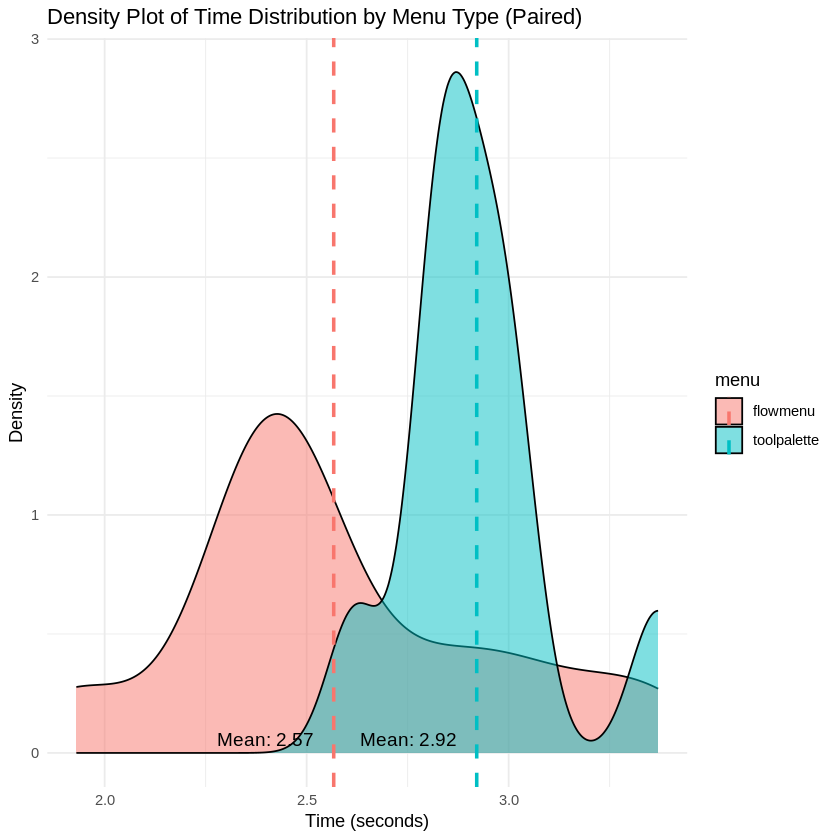

In [12]:
ggplot(dataset2, aes(x = time, fill = menu)) +
  geom_density(alpha = 0.5) +
  labs(title = "Density Plot of Time Distribution by Menu Type (Paired)",
       x = "Time (seconds)", y = "Density") +
  theme_minimal() +
  geom_vline(data = stats, aes(xintercept = mean_time, color = menu), linetype = "dashed", linewidth = 1) +
  geom_text(data = stats, aes(x = mean_time, y = 0, label = paste("Mean:", round(mean_time, 2))),
            color = "black", vjust = -0.5, hjust = 1.2, size = 4)


It can be seen that the overlap of density in paired t test data is lower than that of the unpaired, t test data. Though it can be seen that toolpalette has significantly higher mean time than flow menu. Because of lower overlap in the density plot, we can say that both are statistically different

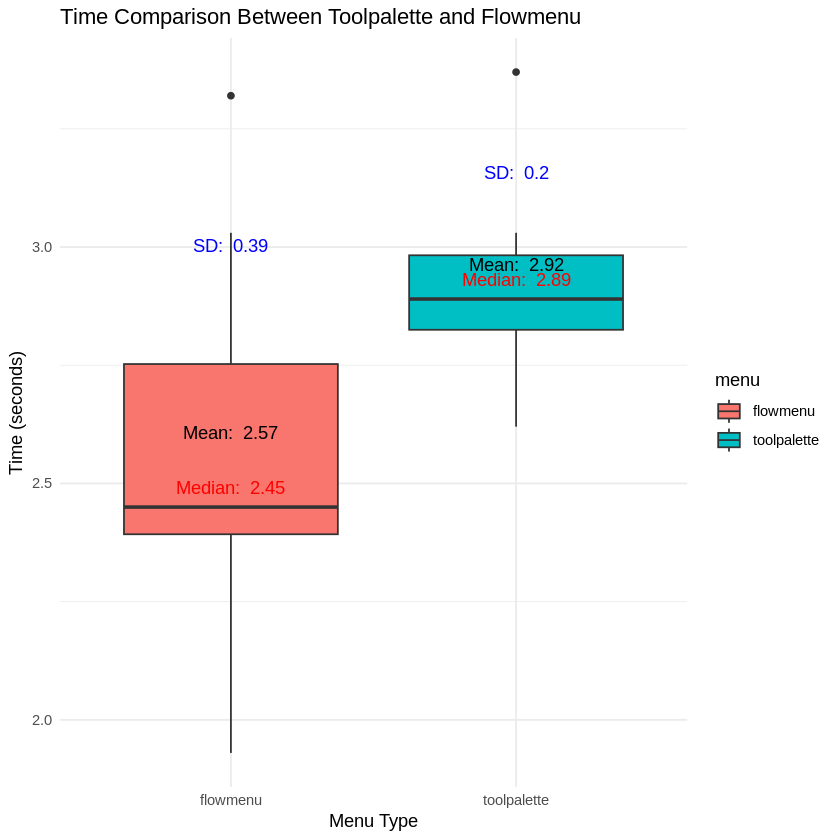

In [17]:
ggplot(dataset2, aes(x = menu, y = time, fill = menu)) +
  geom_boxplot() +
  labs(title = "Time Comparison Between Toolpalette and Flowmenu",
       x = "Menu Type", y = "Time (seconds)") +
  theme_minimal() +
  geom_text(data = stats, aes(x = menu, y = mean_time, label = paste("Mean: ", round(mean_time, 2))),
            vjust = -1, color = "black") +
  geom_text(data = stats, aes(x = menu, y = mean_time + sd_time, label = paste("SD: ", round(sd_time, 2))),
            vjust = -1, color = "blue") +
  geom_text(data = stats, aes(x = menu, y = median_time, label = paste("Median: ", round(median_time, 2))),
            vjust = -1, color = "red")

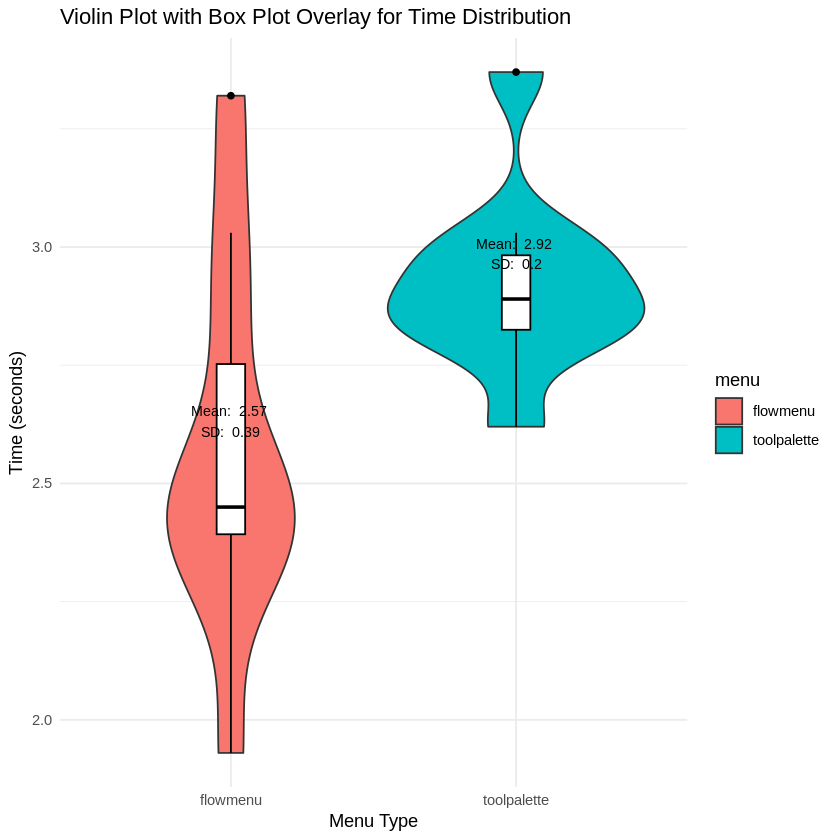

In [13]:
ggplot(dataset2, aes(x = menu, y = time, fill = menu)) +
  geom_violin() +
  geom_boxplot(width = 0.1, color = "black", fill = "white") +
  geom_text(data = stats, aes(x = menu, y = mean_time,
                              label = paste("Mean: ", round(mean_time, 2), "\nSD: ", round(sd_time, 2))),
            color = "black", size = 3, vjust = -0.5) +
  labs(title = "Violin Plot with Box Plot Overlay for Time Distribution",
       x = "Menu Type", y = "Time (seconds)") +
  theme_minimal()

Both the box plot and violin plot depict that the toolpalette has a higher mean time but flowmenu has a higher standard deviation